# <font color='orange'>Course on ADAPTIVE COLLECTIVE SYSTEMS</font>
# <font color='orange'>2. Axelrod's model of collective dissemination</font>

# <font color="green">Cogmaster SUP, 2025-2026</font>

*Teacher: nicolas.bredeche(at)sorbonne-universite.fr*

*Last update: 29/09/2026*


This notebook can be executed in [Google Colab](colab.research.google.com/), Jupyter Lab or Visual Code.


# PLEASE FILL IN THE FOLLOWING BEFORE YOU START:

* Student 1: **_Claus_ _Clarence_ _21618149_**
* Student 2: **_Schätzle_ _Hannes_ _22606428_**

**This lab work is *graded***, which means you are autonomous (ask me if you cannot run the cells below though). Please make pairs. Parts 1 and 2 deal with the basic understanding of the concepts of sociophysics models. Parts 3-5 parts are important but not critical. Part 4 is a bit more technical, but can be addressed with just a few changes in the original code (i.e. you don't need to be a [code wizard](https://nekonaute.gitlab.io/media/random/codewizardry.png)). Part 5 can be answered without code. Please provide clear and *concise* comments.

**LLM policy**: Please do not use LLMs to solve the problem. But you can use them to help with your code. General rule: ask "Tell me how to do ...", don't ask "Do ...". Then, do not copy-paste, but write by yourself what you estimate relevant. You should be able to explain whatever is in your prose and code.

**Submitting your notebook**: you have until this Friday 23:59 to send your notebook by mail (nicolas.bredeche at sorbonne-universite.fr). Your notebook should have all cells with the code *executed* (i.e., results should be visible -- they should match the code, of course). Please attach the notebook (w/o compression) to your mail, and put "***[ACS] labwork***" in the topic. Also, please put your partner as cc:. Good luck !

---
---
---

# <font color='orange'>PREAMBULE: initialization</font>

# Axelrod Model simulator

The Axelrod's model is used to study cultural dissemination in a population of individuals (see slides of my second lecture for an illustrated description).

In its basic form, the model works with a 2-dimensional grid (periodic boundary conditions), with each cell containing an individual. Each individual has a set of N features (e.g. music taste, diet, political opinion, etc.). Each feature is characterize by one specific trait value (e.g. diet can vegetarian, flexitarian, vegan, carnivor, etc.). Individuals can share some cultural traits (e.g. both are vegan), all (e.g. same traits for every features), or none (no overlap).

The Axelrod's model starts with a population of individuals with random traits, and simulate how individuals will influence each other. In practice, the probability of one individual to copy one of its neighbour depends on how similar they are. For each feature, individuals are considered similar only if they have the exact same trait. The similarity between two individuals then depends on the number of features where both have the same trait (this can be normalized in [0,1)).

As an example: if two individuals with 3 features share the same traits for 2 features, then their similarity is 0.66. If two individuals have no feature with a similar trait (ie. similarity is 0.0), then they are considered from two separate cultures and will **never** copy one another. The question is: what is the dynamic of cultural dissemination in a population? When do we converge (or not) towards an homogeneous population?

The algorithm is as follows:

* Step 1. initialize an LxL grid with individuals. Each individual has F features, each feature can take one out of Q possible values.
* Step 2. pick one focal  individual at random, pick one of its neighbour
* Step 3. compute the similarity between the two individuals
* Step 4. the focal individual will copy one feature of the other with a probability that depends on similarity
* Step 5. repeat from Step 2

The important point is that two individuals who are not similar will never interact. Hence, the values of parameters L,F and Q, will have an impact on the number of cultural groups that emerge. In particular, you will observe a phase transition regarding the number of cultures after stabilization if you simulate the model with various parameter values.

About the implementation used for this practical course: individuals will have a fixed number of three features (F=3). Each feature can take one among Q fixed values, defined in [0.0,1.0). This makes it possible to display the grid as a coloured map. Only Q (not F) will be modified throughout this course.

This cell contains all the necessary functions to run Axelrod's model for cultural dissemination. <font color='red'>*This cell **must** be executed before anything else. Unless you modify its content, it is not required to execute it more than once per session.*</font>

In [5]:
from IPython.core import getipython
import sys
import subprocess
execute_in_notebook = True # True if Google Colab or Visual Code ; False if JupyterLab in web -- try both if not sure

#if 'google.colab' in str(getipython.get_ipython()):
#    execute_in_notebook = True
#print("Running in",str(getipython.get_ipython()))

try:
    import google.colab
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numba'])
except ImportError:
    # Not in Google Colab, continue execution normally
    pass

# Import Libraries
import time
from datetime import datetime
from datetime import date
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from numba import njit
from IPython.display import HTML
from matplotlib import rc
import matplotlib as mpl

display_info = True # all other messages
display_full_stats = False # display stats of number of cultures

track_cultures_over_time = True # for every frames, store (#iterations,#cultures) in cultures_over_time
cultures_over_time = [] # Array with structure: (#iterations,#cultures)^N_frames

def set_debug(_display_info = display_info, _display_full_stats = display_full_stats, _track_cultures_over_time = track_cultures_over_time):
    global display_info,display_full_stats,track_cultures_over_time
    display_full_stats = _display_full_stats
    display_info = _display_info
    track_cultures_over_time = _track_cultures_over_time

# Set up Matplotlib to display animations in the notebook
mpl.rcParams['animation.embed_limit'] = 100  # Set the limit to 100 MB or another larger value
rc('animation', html='jshtml')

# Parameters -- DEFAULT VALUES

L = 30  # Squared lattice size
F = 3   # Number of features / traits per agent
Q = -1  # Number of trait values per feature (should be >0)

num_iterations = 20000000 # 20000000 # control parameter -- rule of thumb: > L×L×10. But should be large enough to observe stabilization.
num_frames_displayed = 100 # can be set up by hand (default: 100)
num_iterations_between_frames = int(num_iterations / num_frames_displayed) # number of interaction steps per frame
iterations = 0
im = ax = traits = None

# Precompute neighbor shifts for periodic boundary conditions
neighbor_shifts = np.array([(-1, 0), (1, 0), (0, -1), (0, 1)]) # Von Neumann

@njit
def update_traits(traits, L, F, N_steps, neighbor_shifts):
    for _ in range(N_steps):
        # Select a random agent
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)
        # Select a random neighbor direction
        shift = neighbor_shifts[np.random.randint(0, len(neighbor_shifts))]
        ni = (i + shift[0]) % L
        nj = (j + shift[1]) % L

        # Compute similarity
        distance = np.mean(np.where(traits[i,j]==traits[ni,nj],0,1))
        similarity = 1.0 - distance

        # With probability S, agents interact
        if np.random.rand() < similarity:
            # Select a random trait to adjust
            k = np.random.randint(0, F)
            # Agent i,j adopts the trait from neighbor ni,nj
            traits[i, j, k] = traits[ni, nj, k]
    return traits

def update(frame):
    global traits,iterations,num_iterations_between_frames,im,ax,display_info

    if display_info == True and iterations == 0:
        print ("__________")

    if iterations < num_iterations:
        traits = update_traits(traits, L, F, num_iterations_between_frames, neighbor_shifts)
        iterations = iterations + num_iterations_between_frames
        if display_info == True and iterations%(num_iterations/10) == 0:
            #print (iterations,"/",num_iterations)
            #print (f"{int(iterations/num_iterations*100)}%")
            print (".", end="", flush=True)
            if iterations == num_iterations:
                print()
        if track_cultures_over_time == True:
            cultures_over_time.append([iterations,get_stats()[0]])

    # Update the image data
    im.set_data(traits)
    #ax.set_title(f"Iteration: {frame * N_steps}")
    ax.set_title(f"Q={Q},F={F},arena={L}x{L}\nIterations: {int(iterations)} / {num_iterations} ({int(iterations/num_iterations*100)}%)")
    return [im]

def get_stats():
    global traits

    arr_2d = traits.reshape(-1, 3)
    arr_rounded = np.round(arr_2d, decimals=8)  # Round to reduce floating-point errors
    unique_vectors, counts = np.unique(arr_rounded, axis=0, return_counts=True)
    num_unique_vectors = unique_vectors.shape[0]
    sorted_indices = np.argsort(-counts)
    sorted_vectors = unique_vectors[sorted_indices]
    sorted_counts = counts[sorted_indices]

    return num_unique_vectors,sorted_vectors,sorted_counts

def display_plot(data):
    global L

    data = np.array(data)
    x = data[:, 0]
    y = data[:, 1]
    plt.figure(figsize=(6, 4))
    plt.plot(x, y, marker='o', linestyle='-', color='b', label='Data')
    plt.xlabel('iterations') # NOT plt.xlabel('#cultures')
    plt.ylabel('#cultures') # NOT plt.ylabel('iterations')
    plt.title(f"Q={Q},F={F},arena={L}x{L}\ncultural dissemination over time")
    #plt.legend()
    plt.ylim(0, min(L*L,Q**F))
    plt.grid(True)
    plt.show()

def run(_Q, _F = F, _L = L, _num_iterations = num_iterations, _num_frames_displayed = num_frames_displayed):
    global L,F,Q,num_iterations,num_frames_displayed,traits,im,ax,iterations,display_info,display_stats,display_graphics,cultures_over_time,num_iterations_between_frames

    start_time = time.time()

    Q = _Q
    F = _F
    L = _L
    num_iterations = _num_iterations
    num_frames_displayed = _num_frames_displayed
    num_iterations_between_frames = int(num_iterations / num_frames_displayed) # must be updated
    iterations = 0

    im = ax = traits = None

    cultures_over_time = []

    # Generate Q distinct real values between 0 and 1
    values = np.linspace(0, 1, Q, endpoint=False) + (0.5 / Q)  # Shift to avoid including 0
    traits = np.random.choice(values, size=(L, L, F))
    #print (traits)

    # Set up the plot
    fig, ax = plt.subplots()
    im = ax.imshow(traits, interpolation='nearest', animated=True)
    ax.axis('off')

    # Display information
    if display_info == True:
        print ("=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=")
        print ("Arena                  :",L,"x",L)
        print ("Number of features     :",F)
        print ("Number of trait values :",Q)
        print ("Iterations             :",num_iterations)
        print ("Display",num_frames_displayed,"frames (ie. every",num_iterations_between_frames,"iterations)")

    # Create the animation
    if track_cultures_over_time == True:
        cultures_over_time.append([iterations,get_stats()[0]])

    ani = FuncAnimation(fig, update, frames=num_frames_displayed-1, blit=True, repeat=False, interval=1)

    # Display the animation
    if execute_in_notebook == False:
        plt.show() # from terminal
    else:
        display(HTML(ani.to_jshtml())) # from a Google Colab notebook

    final_num_unique_vectors,final_sorted_vectors,final_sorted_counts = get_stats()

    if display_info == True:
        print("Number of unique cultures:", final_num_unique_vectors)
    if display_full_stats == True:
        print("List of cultures (with surface):")
        for vector, count in zip(final_sorted_vectors, final_sorted_counts):
            print("Vector:", vector, "Count:", count)

    if track_cultures_over_time == True:
        display_plot(cultures_over_time)

    end_time = time.time()
    elapsed_time = end_time - start_time
    if display_info == True:
        print(f"{elapsed_time:.1f} sec.")

    return (final_num_unique_vectors, final_sorted_vectors, final_sorted_counts, cultures_over_time)



#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")



 2026-09-29 16:49:22 GMT
OK.


---
---
---

# <font color='orange'>PART 1: simulating cultural dissemination</font>

- run the two cells below, make sure you understand the set_debug and run functions, as used below.
- analyse the outcome of the two simulations. What do you conclude?

**Methodological hint**: *Simulation is stochastic. Run multiple simulations with the same set of parameters to obtain reliable results.*

**Technical hint**: *Simulation takes time. Be careful when setting arena size, and number of frames to be rendered.*

=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
Arena                  : 20 x 20
Number of features     : 3
Number of trait values : 18
Iterations             : 5000000
Display 100 frames (ie. every 50000 iterations)
__________
..........


Number of unique cultures: 227


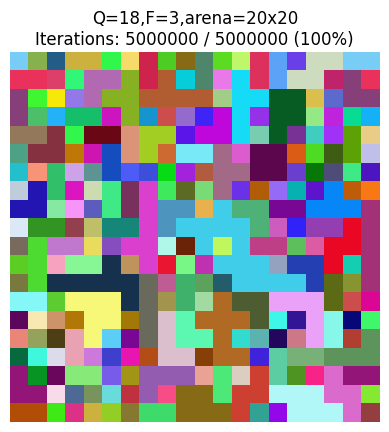

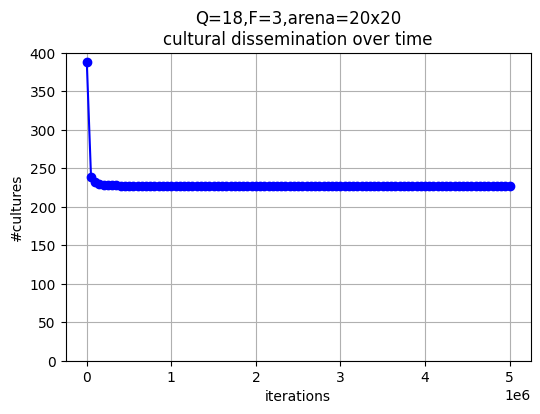

4.0 sec.


In [7]:
set_debug(_display_info=True,
          _display_full_stats=False,
          _track_cultures_over_time=True)
retValues = run( _Q=18, _F=3, _L=20, _num_iterations = 5000000, _num_frames_displayed = 100 )

=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
Arena                  : 20 x 20
Number of features     : 3
Number of trait values : 5
Iterations             : 5000000
Display 100 frames (ie. every 50000 iterations)
__________
..........


Number of unique cultures: 1


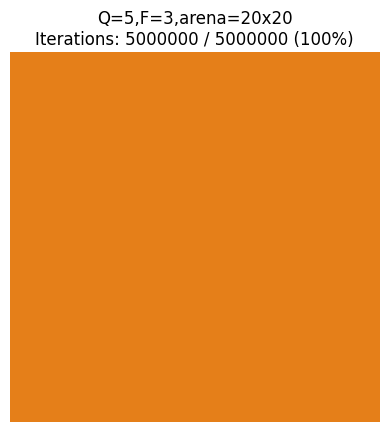

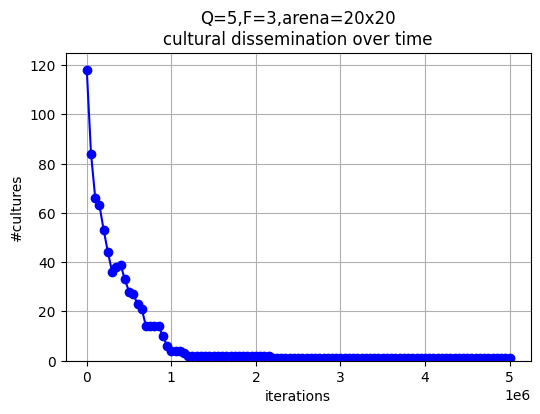

4.0 sec.


In [8]:
set_debug(_display_info=True,
          _display_full_stats=False,
          _track_cultures_over_time=True)
retValues = run( _Q=5, _F=3, _L=20, _num_iterations = 5000000, _num_frames_displayed = 100 )

<font color='green'>Your comments:</green>

The first simulations with $Q=18$ reaches the absorbing state "fragmentation". This occurs because the similarity between the focal agent and its neighbour determines the probability of them interacting. Fragmentation is the state where the neighboring pairs cannot interact with each other anymore, either because there is no similarity in their culture( so the probability for interaction is $0$), or because they are already identical and copying changes nothing. The starting point were $18^3$ possible distinct cultures, and after $50000000$ iterations it converged to $227$ distinct cultures.

The second simulations with $Q=5$ reaches the absorbing state "consensus". Here the neighboring pairs all converge to the same traits, and have the same culture. They cannot interact anymore, because copying would not change anything. This happened after $2200000$ iterations.

---
---
---

# <font color='orange'>PART 2: revealing a phase transition</font>

- Find whether there  is a phase transition w.r.t. the number of traits (Q). Show a figure with the number of cultures (Y-axis) obtained with different Q values (X-axis) after stabilization.

**Methodological hint**: *The phase transition may not be sharp. Consider a careful exploration of Q values around the phase transition, and larger steps outside.*

**Technical hint**: *You can use either plot function defined in the first cell (copy and modify it) or an external tool (e.g. Libroffice, google spreadsheet)*

**Technical hint**: *the run(-) function returns some statistics in a structure array. The first component of the array (e.g. retValues[0]) contains the number of cultures at the end of a simulation*

**Technical hint**: *you can call several run(-) functions in sequence within the same cell.*

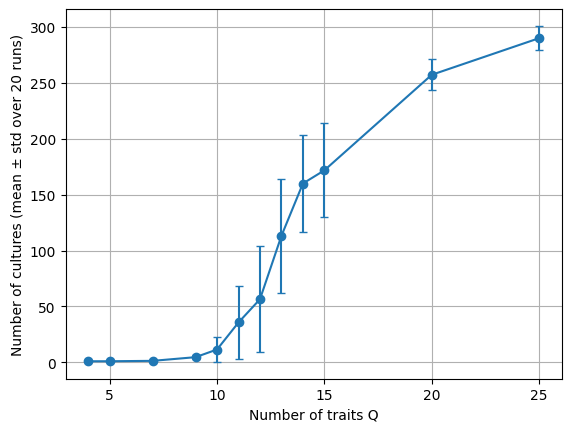

In [13]:
# your code

# Using the relevant parts of the run function and the counting part of get_stats()
# to skip the animation and make the simulations faster.
def run_fast(Q, L=20, F=3, n_iter=5_000_000):
    values = np.linspace(0, 1, Q, endpoint=False) + 0.5/Q
    grid = np.random.choice(values, size=(L, L, F))
    grid = update_traits(grid, L, F, n_iter, neighbor_shifts)
    return np.unique(np.round(grid.reshape(-1, F), 8), axis=0).shape[0]

num_traits = [4,5,7,9,10,11,12,13,14,15,20,25,30]
num_cultures = []
R = 20
means = []
stds = []

for q in num_traits:
    results = []
    for r in range(R):
        results.append(run_fast(Q=q, F=3, L=20, n_iter=10_000_000))
    means.append(np.mean(results))
    stds.append(np.std(results))

plt.errorbar(num_traits, means, yerr=stds, marker='o', capsize=3)
plt.xlabel("Number of traits Q")
plt.ylabel("Number of cultures (mean ± std over %d runs)" % R)
plt.grid(True)
plt.show()


<font color='green'>Your comments:</green>

There is a phase transition occurring between $Q=7$ and starts to stabilize at $Q=25$.

---
---
---

# <font color='orange'>PART 3: Parameter sensitivity and model implementation</font>

- Reveal the phase transition (using Q) with a larger arena (try with 30x30). Revert to 20x20 after this question.
- Reveal the phase transition (using Q) with a *Moore* neighborhood (ie. 8 neighbours). Revert to the original *Von Neumann* neighborhood (ie. 4 neighbours) after this question.

**Methodological hint**: *take a look at update_traits(-) in the first cell (relevant for question 2).*





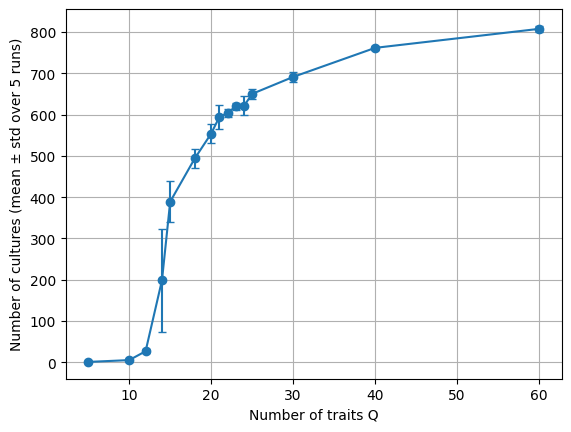

In [28]:
# your code
# Larger arena (30x30)
# Adding a frozen state function, to avoid explosion of iterations and make runtime more efficient
neighbor_shifts = np.array([(-1, 0), (1, 0), (0, -1), (0, 1)]) # Von Neumann


def is_frozen(grid, F, shifts):
    # frozen = every neighbouring pair shares either 0 or all F features
    for di, dj in shifts:
        neighbour = np.roll(grid, (-di, -dj), axis=(0, 1))   # periodic neighbour of every cell
        shared = (grid == neighbour).sum(axis=2)             # shared features per pair, shape (L, L)
        if not np.all((shared == 0) | (shared == F)):
            return False
    return True

def run_fast(Q, L=20, F=3, n_iter=5_000_000, chunk=100_000, shifts=neighbor_shifts):
    values = np.linspace(0, 1, Q, endpoint=False) + 0.5/Q
    grid = np.random.choice(values, size=(L, L, F))
    done = 0
    while done < n_iter:
        steps = min(chunk, n_iter - done)
        grid = update_traits(grid, L, F, steps, shifts)
        done += steps
        if is_frozen(grid, F, shifts):
            break
    n_cultures = np.unique(np.round(grid.reshape(-1, F), 8), axis=0).shape[0]
    return n_cultures, done

num_traits = [5,10,12,14,15,18,20,21,22,23,24,25,30,40,60]
num_cultures = []
R = 5
means = []
stds = []

for q in num_traits:
    results = []
    for r in range(R):
        n, it = run_fast(Q=q, F=3, L=30, n_iter=50_000_000)
        results.append(n)
    means.append(np.mean(results))
    stds.append(np.std(results))


plt.errorbar(num_traits, means, yerr=stds, marker='o', capsize=3)
plt.xlabel("Number of traits Q")
plt.ylabel("Number of cultures (mean ± std over %d runs)" % R)
plt.grid(True)
plt.show()

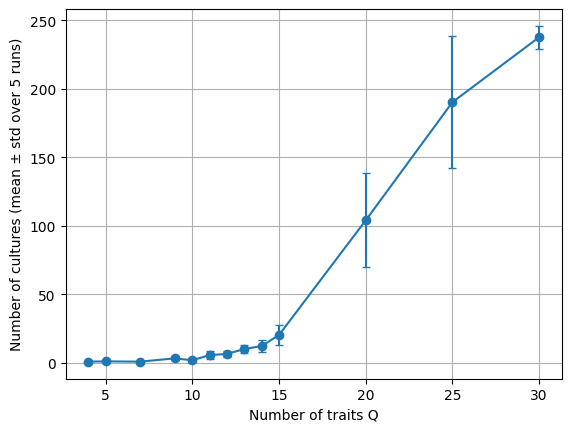

In [27]:
# your code
# HS: Adding a frozen state function, to avoid explosion of iterations and make runtime more efficient
neighbor_shifts = np.array([(-1, 0), (-1,1), (1, 0), (1,1), (0, -1), (1,-1), (0, 1), (-1,-1)]) # Moore

def is_frozen(grid, F, shifts):
    # frozen = every neighbouring pair shares either 0 or all F features
    for di, dj in shifts:
        neighbour = np.roll(grid, (-di, -dj), axis=(0, 1))   # periodic neighbour of every cell
        shared = (grid == neighbour).sum(axis=2)             # shared features per pair, shape (L, L)
        if not np.all((shared == 0) | (shared == F)):
            return False
    return True

def run_fast(Q, L=20, F=3, n_iter=5_000_000, chunk=100_000, shifts=neighbor_shifts):
    values = np.linspace(0, 1, Q, endpoint=False) + 0.5/Q
    grid = np.random.choice(values, size=(L, L, F))
    done = 0
    while done < n_iter:
        steps = min(chunk, n_iter - done)
        grid = update_traits(grid, L, F, steps, shifts)
        done += steps
        if is_frozen(grid, F, shifts):
            break
    n_cultures = np.unique(np.round(grid.reshape(-1, F), 8), axis=0).shape[0]
    return n_cultures, done

num_traits = [5,10,12,14,15,18,20,21,22,23,24,25,30,40,60]
num_cultures = []
R = 5
means = []
stds = []

for q in num_traits:
    results = []
    for r in range(R):
        n, it = run_fast(Q=q, F=3, L=20, n_iter=50_000_000)
        results.append(n)
    means.append(np.mean(results))
    stds.append(np.std(results))


plt.errorbar(num_traits, means, yerr=stds, marker='o', capsize=3)
plt.xlabel("Number of traits Q")
plt.ylabel("Number of cultures (mean ± std over %d runs)" % R)
plt.grid(True)
plt.show()

<font color='green'>Your comments:</green>

In a larger arena (size 30x30) the pseudo-critical point of phase transition occurs later, compared to a smaller arena. While in the smaller (20x20) arena it occurred around $Q=10$, in the larger arena it occurred around $Q=15$.

Increasing the neighborhood size from a von Neumann to a Moore architecture also delays the pseudo-critical point of the phase transition to approximately Q=$15$.

---
---
---

# <font color='orange'>PART 4: Topological considerations</font>

The current arena is periodic (ie. a torus, not a sheet of paper). We will now study what happens when the topology is different.

- Set up an arena with walls on the borders. The idea is to experiment with an aperiodic 2D space. Compare with original setting.
- Set up an arena in which living individuals form a ring (ie. individuals have only two neighbours). Compare with original setting.
- Set up an arena in which living individuals form two highly interconnected groups (e.g. two squared lattices), which are connected by a single individual. Compare with original setting.

**methodological hint**: *when comparing the periodic vs aperiodic 2D space, consider having the same number of individuals in the arena (ie. same number of individuals in both cases)*

**technical hint**: *Copy and modify the original code so that a cell bearing traits with negative values is ignored. Such a "dead" cell will never interact (you can see it as a wall). You will have (1) to skip update for dead cells; (2) ignore them when updating another cell; (3) ignore them when counting cultures (this step may be skipped).*



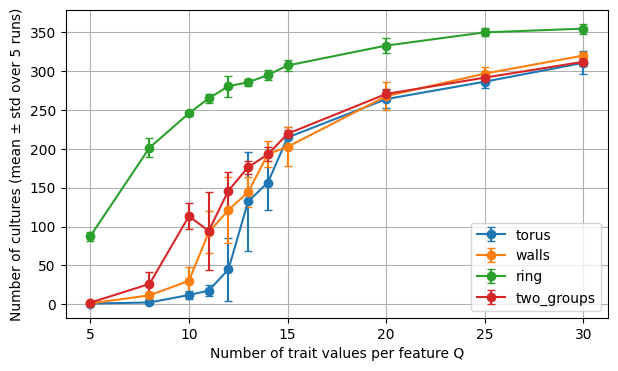

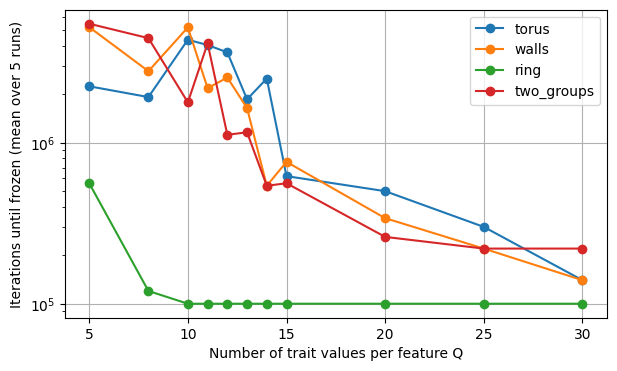

two_groups: number of cultures in each run
  Q= 5: [2, 3, 1, 4, 1]
  Q= 8: [29, 30, 51, 8, 13]
  Q=10: [106, 86, 114, 129, 132]
  Q=11: [125, 114, 37, 35, 161]
  Q=12: [145, 110, 185, 146, 145]
  Q=13: [169, 170, 191, 171, 181]
  Q=14: [187, 182, 207, 189, 199]
  Q=15: [228, 220, 216, 216, 217]
  Q=20: [278, 270, 274, 272, 259]
  Q=25: [287, 297, 291, 288, 295]
  Q=30: [316, 315, 301, 311, 317]


In [32]:
# your code

# Disclosure by HS: Some of the code below was generated using large language models. I will mark the parts that were produced using LLMs.
@njit
def update_traits_dead(traits, F, N_steps, shifts):
    rows = traits.shape[0]
    cols = traits.shape[1]
    for _ in range(N_steps):
        i = np.random.randint(0, rows)
        j = np.random.randint(0, cols)
        if traits[i, j, 0] < 0:            # (1) dead focal cell -> skip
            continue
        shift = shifts[np.random.randint(0, len(shifts))]
        ni = (i + shift[0]) % rows
        nj = (j + shift[1]) % cols
        if traits[ni, nj, 0] < 0:          # (2) dead neighbour -> skip
            continue
        distance = np.mean(np.where(traits[i, j] == traits[ni, nj], 0, 1))
        similarity = 1.0 - distance
        if np.random.rand() < similarity:
            k = np.random.randint(0, F)
            traits[i, j, k] = traits[ni, nj, k]
    return traits

def count_cultures(grid, F):
    cells = np.round(grid.reshape(-1, F), 8)
    alive = cells[cells[:, 0] >= 0]        # (3) ignore dead cells when counting
    return np.unique(alive, axis=0).shape[0]


VN_shifts   = np.array([(-1, 0), (1, 0), (0, -1), (0, 1)])
RING_shifts = np.array([(0, -1), (0, 1)])

def random_traits(shape, Q):
    values = np.linspace(0, 1, Q, endpoint=False) + 0.5/Q
    return np.random.choice(values, size=shape)


# LLM: The make_arena function was generated using Claude, but after defining the topologies logically first.
def make_arena(topology, Q, F=3):
    if topology == "torus":                 # original setting, for comparison
        grid = random_traits((20, 20, F), Q)
        shifts = VN_shifts
    elif topology == "walls":               # 20x20 sheet inside a dead border
        grid = random_traits((22, 22, F), Q)
        grid[0, :, :] = -1
        grid[-1, :, :] = -1
        grid[:, 0, :] = -1
        grid[:, -1, :] = -1
        shifts = VN_shifts
    elif topology == "ring":                # one row of 400, wrap-around closes the ring
        grid = random_traits((1, 400, F), Q)
        shifts = RING_shifts
    elif topology == "two_groups":          # two 20x10 blocks joined by one individual
        grid = random_traits((22, 23, F), Q)
        grid[0, :, :] = -1
        grid[-1, :, :] = -1
        grid[:, 0, :] = -1
        grid[:, -1, :] = -1
        grid[:, 11, :] = -1                 # dead column splits the arena in two
        grid[10, 11, :] = random_traits((F,), Q)   # the bridge individual
        shifts = VN_shifts
    else:
        raise ValueError("unknown topology: " + topology)
    return grid, shifts


# LLM: The run_topology function was generated using Claude, but after defining that it should take the run_fast function as inspiration.
def run_topology(topology, Q, F=3, n_iter=50_000_000, chunk=100_000):
    grid, shifts = make_arena(topology, Q, F)
    done = 0
    while done < n_iter:
        steps = min(chunk, n_iter - done)
        grid = update_traits_dead(grid, F, steps, shifts)
        done += steps
        if is_frozen(grid, F, shifts):
            break
    return count_cultures(grid, F), done

topologies = ["torus", "walls", "ring", "two_groups"]
num_traits = [5, 8, 10, 11, 12, 13, 14, 15, 20, 25, 30]
R = 5
n_iter = 50_000_000

mean_cultures = {}
std_cultures = {}
mean_iters = {}
raw_counts = {}
n_capped = {}

# Adjusted from the previous part's code. Not generated using LLM.
for t in topologies:
    mean_cultures[t], std_cultures[t], mean_iters[t], raw_counts[t] = [], [], [], []
    n_capped[t] = 0
    for q in num_traits:
        counts, its = [], []
        for r in range(R):
            n, it = run_topology(t, q, n_iter=n_iter)
            counts.append(n)
            its.append(it)
            if it == n_iter:
                n_capped[t] += 1
        mean_cultures[t].append(np.mean(counts))
        std_cultures[t].append(np.std(counts))
        mean_iters[t].append(np.mean(its))
        raw_counts[t].append(counts)

# LLM: Plots were generated using LLM.
plt.figure(figsize=(7, 4))
for t in topologies:
    plt.errorbar(num_traits, mean_cultures[t], yerr=std_cultures[t], marker='o', capsize=3, label=t)
plt.xlabel("Number of trait values per feature Q")
plt.ylabel("Number of cultures (mean ± std over %d runs)" % R)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
for t in topologies:
    plt.plot(num_traits, mean_iters[t], marker='o', label=t)
plt.xlabel("Number of trait values per feature Q")
plt.ylabel("Iterations until frozen (mean over %d runs)" % R)
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

print("two_groups: number of cultures in each run")
for q, counts in zip(num_traits, raw_counts["two_groups"]):
    print(f"  Q={q:2d}: {counts}")



<font color='green'>Your comments:</green>

Walls: With walls on the borders the curve stays close to the original torus, but the pseudo-critical point of the phase transition occurs slightly earlier.

Ring: The phase transition disappears from the observed range, even with $Q=5$, where the torus always reaches consensus, the ring reaches the absorbing state "fragmentation" with around 90 cultures

Two groups connected by a single individual: The two groups (two 20x10 blocks plus one bridge, 401 individuals) never reached consensus in our 5 runs with $Q=5$ (2, 4, 2, 2, 4 cultures), while the torus always did.

So over all, the topology changes where the pseudo-critical point occurs. The fewer neighbours an individual has (torus 4, walls 3 to 4, ring 2) and the fewer alternative paths exist between two individuals (one bridge), the earlier the transition from consensus to fragmentation occurs.


---
---
---

# <font color='orange'>PART 5: Open questions</font>

- What happens if similarity is computed as an euclidian distance?
- What happens if thermal noise is added during copy?
- What happens if thermal noise spontaneous occurs even when not copying?
- What would be the point of adding thermal noise anyway?

In [ ]:
# your code, optional -- not needed to answer.


<font color='green'>Your comments:</green>

- What happens if similarity is computed as an euclidian distance?

In the original model the trait values are only labels. Two traits are either identical or different. With an euclidean distance the values become ordered and "close" traits count as partially similar. The similarity is then almost never exactly $0$, so the barrier that prevents dissimilar agents from interacting disappears, and frozen frontiers cannot form, the population almost always ends in consensus, and the phase transition in $Q$ disappears.
This would be closer to the Deffuant version of the Axelrod model; if agents are close enough in the space, they are allowed to interact.
This is implemented by introducing a tolerance threshold $\epsilon$ (how tolerant agents are to others opinions), and a convergence factor $\mu$ (how much the opinions in the $n$ dimensional space are adjusted). The absorbing states (whether consensus or fragmentation is reached) depend on $\epsilon$, whereas the speed of convergence depends on $\mu$.

- What happens if thermal noise is added during copy?

If thermal noise is added during copy, the interaction rule itself does not change, but the absorbing states are lost. Exact consensus is never reached.


- What happens if thermal noise spontaneous occurs even when not copying?

Can create small islands; frontiers can be broken up; for a small probability it creates consensus with drift (towards new values), whereas for larger probabilities it adds disruption. In the long term this leads to independence from initial conditions.

- What would be the point of adding thermal noise anyway?
Without noise the model only has absorbing states. Once frozen nothing can change, and the final state depends on the initial random configuration.

